In [ ]:
!pip install google-cloud-bigquery pandas pyarrow -q

from google.colab import auth, files
from google.cloud import bigquery
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from scipy.stats import pearsonr, shapiro, ttest_rel, wilcoxon, chisquare, chi2_contingency, fisher_exact
from itertools import combinations

from IPython.display import display, HTML


auth.authenticate_user()
client = bigquery.Client(project="data-analytics-mate")

In [ ]:
## Helper function

## Number formatting functions
def format_k(value, pos=None):
    if value >= 1000:
        return f"{value / 1000:.0f}K"
    return f"{value:.0f}"

from matplotlib.ticker import FuncFormatter

def format_money(value, pos=None):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.0f}M"
    elif value >= 1000:
        return f"{value / 1000:.0f}K"
    return f"{value:.0f}"

## Plotting Helper function
def plot_revenue_dynamics(data, hue_col, title, legend_title):
    data = data.copy()
    data["session_date"] = pd.to_datetime(data["session_date"])
    data = data.sort_values("session_date")

    plt.figure(figsize=(14, 6))

    ax = sns.lineplot(
        data=data,
        x="session_date",
        y="revenue",
        hue=hue_col,
        marker="o"
    )

    plt.title(title, fontsize=16, pad=20)
    plt.xlabel("", fontsize=12)
    plt.ylabel("Revenue ($)", fontsize=12)

    ax.yaxis.set_major_formatter(FuncFormatter(format_money))

    plt.xticks(rotation=45)
    plt.legend(title=legend_title, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Function for statistic analysis
def statistic_analysis(
    data,
    param1,
    param2,
    aggfunc,
    top_numeric=None,
    index="session_date",
    alpha=0.05
):
    if top_numeric is not None:
        top_params = (
            data.groupby(param1)[param2]
            .agg(aggfunc)
            .sort_values(ascending=False)
            .head(top_numeric)
            .index
            .tolist()
        )

        filtered_data = data[data[param1].isin(top_params)]
    else:
        filtered_data = data[data[param1].notna()]

    sales_by_data_datetime = pd.pivot_table(
        filtered_data,
        index=index,
        columns=param1,
        values=param2,
        aggfunc=aggfunc,
        fill_value=0
    )

    corr_matrix = sales_by_data_datetime.corr()

    results = []

    for c1, c2 in combinations(sales_by_data_datetime.columns, 2):
        x = sales_by_data_datetime[c1]
        y = sales_by_data_datetime[c2]

        if x.nunique() > 1 and y.nunique() > 1:
            r, p = pearsonr(x, y)
        else:
            r, p = np.nan, np.nan

        results.append({
            "group_1": c1,
            "group_2": c2,
            "correlation": r,
            "p_value": p,
            "is_significant": p < alpha if not np.isnan(p) else False
        })

    statistic_result = pd.DataFrame(results)

    return sales_by_data_datetime, corr_matrix, statistic_result

In [ ]:
## Data Loading
sql = """
SELECT
  s.date AS session_date,
  s.ga_session_id,

  sp.continent,
  sp.country,
  sp.device,
  sp.browser,
  sp.mobile_model_name,
  sp.operating_system,
  sp.language,

  sp.medium AS traffic_medium,
  sp.name AS traffic_source,
  sp.channel AS traffic_channel,

  acc.id AS account_id,

  CASE
    WHEN acc.is_verified IS NULL THEN NULL
    ELSE acc.is_verified
  END AS is_email_verified,

  CASE
    WHEN acc.id IS NULL THEN NULL
    WHEN acc.is_unsubscribed = 1 THEN 0
    WHEN acc.is_unsubscribed = 0 THEN 1
    ELSE NULL
END AS is_subscribed,

  p.category,
  p.name AS product_name,
  p.price,
  p.short_description

FROM `data-analytics-mate.DA.session` s

LEFT JOIN `data-analytics-mate.DA.order` o
  ON s.ga_session_id = o.ga_session_id

LEFT JOIN `data-analytics-mate.DA.session_params` sp
  ON s.ga_session_id = sp.ga_session_id

LEFT JOIN `data-analytics-mate.DA.account_session` acs
  ON s.ga_session_id = acs.ga_session_id

LEFT JOIN `data-analytics-mate.DA.account` acc
  ON acs.account_id = acc.id

LEFT JOIN `data-analytics-mate.DA.product` p
  ON o.item_id = p.item_id
"""

query_work = client.query(sql)

df = query_work.to_dataframe(create_bqstorage_client=False)
df.head()

,session_date,ga_session_id,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_medium,traffic_source,traffic_channel,account_id,is_email_verified,is_subscribed,category,product_name,price,short_description
0,2020-11-01,967742695,Americas,United States,desktop,Safari,Safari,Web,en-us,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,9065007548,Asia,China,desktop,Chrome,Safari,Web,None,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3267062634,Americas,United States,desktop,Chrome,Safari,Web,en-us,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
3,2020-11-01,8892952409,Americas,United States,mobile,Android Webview,<Other>,Web,ko,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,None,None,NaN,None
4,2020-11-01,1624570787,Asia,Turkey,desktop,<Other>,<Other>,Web,en-us,(data deleted),(data deleted),Undefined,<NA>,<NA>,<NA>,None,None,NaN,None


##**Brief description of the dataset**


In [ ]:
funnel_dimension = pd.DataFrame({
    "funnel_order": [1, 2, 3],
    "funnel_stage": [
        "Sessions",
        "Registered Users",
        "Verified Users"
    ],
    "funnel_value": [
        df["ga_session_id"].nunique(),
        df.loc[df["account_id"].notna(), "account_id"].nunique(),
        df.loc[df["is_email_verified"] == 1, "account_id"].nunique()
    ]
})
funnel_dimension



,funnel_order,funnel_stage,funnel_value
0,1,Sessions,349545
1,2,Registered Users,27945
2,3,Verified Users,20036


In [ ]:
print("Total count of columns:", len(df.columns))

datetime_columns = df.select_dtypes(include=["datetime64"]).columns

print("Count of datetime columns:", len(datetime_columns))
print("Datetime columns:", list(datetime_columns))

numeric_columns = df.select_dtypes(include=[np.number]).columns
print("Count of numeric columns:", len(numeric_columns))
print("Numeric columns:", list(numeric_columns))

categorical_columns = df.select_dtypes(include=["object"]).columns
print("Count of categorical columns:", len(categorical_columns))
print("Categorical columns:", list(categorical_columns))

unique_session_count = len(np.unique(list(df["ga_session_id"])))
print("Count of unique sessions:", unique_session_count)

min_session_date = np.min(df["session_date"])
max_session_date = np.max(df["session_date"])
print("The time period from", min_session_date, "to",max_session_date)


missing_report = df.isnull().sum().reset_index()
missing_report.columns = ["column_name", "missing_count"]
missing_report = missing_report[missing_report["missing_count"] > 0]

display("Missing report", missing_report)


Total count of columns: 19
Count of datetime columns: 0
Datetime columns: []
Count of numeric columns: 5
Numeric columns: ['ga_session_id', 'account_id', 'is_email_verified', 'is_subscribed', 'price']
Count of categorical columns: 13
Categorical columns: ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'traffic_medium', 'traffic_source', 'traffic_channel', 'category', 'product_name', 'short_description']
Count of unique sessions: 349545
The time period from 2020-11-01 to 2021-01-31


'Missing report'

,column_name,missing_count
8,language,114266
12,account_id,321600
13,is_email_verified,321600
14,is_subscribed,321600
15,category,316007
16,product_name,316007
17,price,316007
18,short_description,316007


The highest number of missing values ​​is observed in the columns containing product information and the account ID. This is because the dataset includes all user sessions, including those where no order was placed and those where the user was not identified. Additionally, there are missing values ​​in the "language" column, as not all users transmit their browser or system language.

In [ ]:
session_cnt = df["ga_session_id"].nunique()
registered_users = df["account_id"].nunique()
registered_sessions_count = df[df["account_id"].notna()]["ga_session_id"].nunique()
registration_rate = registered_sessions_count / session_cnt * 100
verified_users = df[df["is_email_verified"] > 0]["account_id"].nunique()
verified_rate = verified_users / registered_users * 100
subscribed_users = df[df["is_subscribed"] > 0]["account_id"].nunique()
subscribed_rate = subscribed_users / registered_users * 100
session_cnt_with_orders = df[df["product_name"].notna()]["ga_session_id"].nunique()
session_to_orders_rate = session_cnt_with_orders / session_cnt * 100
total_revenue = df["price"].sum()
avg_order_value = df["price"].mean()


In [ ]:
# @title
display(HTML(f"""
<h2>KPI Cards</h2>
<div style="display:flex; gap:15px; flex-wrap:wrap;">

<div style="padding:15px; border-radius:10px; border:1px solid #ddd; width:180px">
<h4>Total Sessions</h4>
<h2>{session_cnt:,.0f}</h2>
</div>

<div style="padding:15px; border-radius:10px; border:1px solid #ddd; width:180px">
<h4>Registration Rate</h4>
<h2>{registration_rate:.2f}%</h2>
</div>

<div style="padding:15px; border-radius:10px; border:1px solid #ddd; width:180px">
<h4>Verified Rate</h4>
<h2>{verified_rate:.2f}%</h2>
</div>

<div style="padding:15px; border-radius:10px; border:1px solid #ddd; width:180px">
<h4>Subscribed Rate </h4>
<h2>{subscribed_rate:.2f}%</h2>
</div>

<div style="padding:15px; border-radius:10px; border:1px solid #ddd; width:180px">
<h4>Total Revenue</h4>
<h2>${total_revenue:,.0f}</h2>
</div>

<div style="padding:15px; border-radius:10px; border:1px solid #ddd; width:180px">
<h4>Sessions with Orders</h4>
<h2>{session_cnt_with_orders:,}</h2>
</div>

<div style="padding:15px; border-radius:10px; border:1px solid #ddd; width:180px">
<h4>Average Product Price</h4>
<h2>${avg_order_value:,.0f}</h2>
</div>

<div style="padding:15px; border-radius:10px; border:1px solid #ddd; width:180px">
<h4>Session to Order Conversion</h4>
<h2>{session_to_orders_rate:.2f}%</h2>
</div>

</div>
"""))

##**Sessions and Orders Overview**

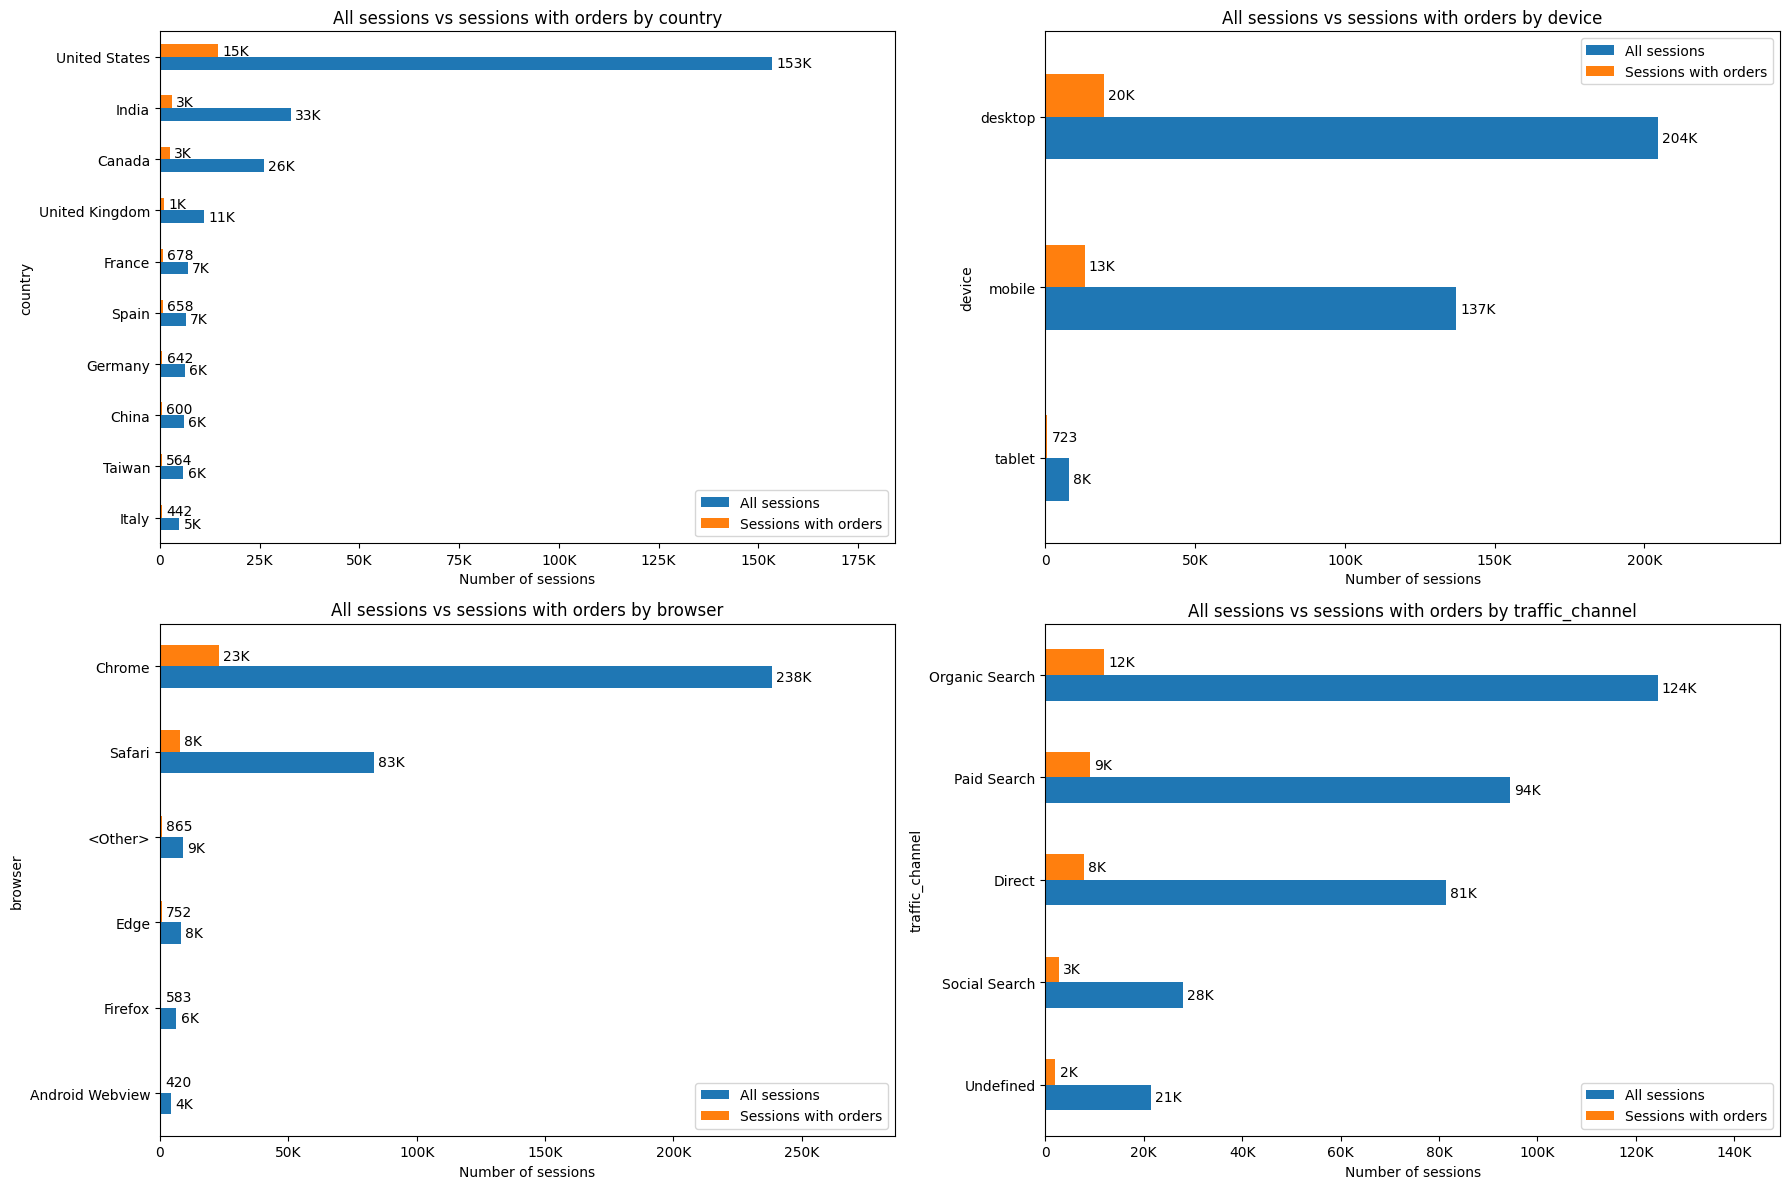

In [ ]:
columns_for_distribution = [
    "country",
    "device",
    "browser",
    "traffic_channel"
]

df_with_orders = df[df["product_name"].notna()]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, column in enumerate(columns_for_distribution):
    all_sessions = df[column].fillna("Unknown").value_counts()
    sessions_with_orders = df_with_orders[column].fillna("Unknown").value_counts()

    comparison = pd.DataFrame({
        "All sessions": all_sessions,
        "Sessions with orders": sessions_with_orders
    }).fillna(0)

    comparison = comparison.sort_values("All sessions", ascending=False).head(10)
    comparison = comparison.sort_values("All sessions")

    ax = axes[i]

    comparison.plot(
        kind="barh",
        ax=ax
    )

    ax.set_title(f"All sessions vs sessions with orders by {column}")
    ax.set_xlabel("Number of sessions")
    ax.set_ylabel(column)

    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: format_k(x))
    )

    for container in ax.containers:
        labels = [format_k(value) for value in container.datavalues]
        ax.bar_label(
            container,
            labels=labels,
            label_type="edge",
            padding=3
        )

    max_value = comparison.max().max()
    ax.set_xlim(0, max_value * 1.2)

plt.tight_layout()
plt.show()

The dataset contains 349,545 user sessions, and 33,538 of them ended with an order. The overall session-to-order conversion rate is 9.59%, which means that about one in ten sessions resulted in a purchase.

Most sessions and orders come from the largest traffic segments: United States, desktop users, Chrome browser, and the main traffic channels such as Organic Search, Paid Search, and Direct. Their conversion rates are close to the overall average, so the number of orders is mainly driven by traffic volume.

Desktop and mobile traffic perform almost equally well, while tablet traffic has a slightly lower conversion rate. Among browsers, Chrome and Safari bring the largest number of sessions and orders, with conversion rates close to the average.

The Undefined traffic channel has a much lower conversion rate compared to the main channels. This may indicate lower traffic quality or tracking issues, so it should be analyzed separately.

In [ ]:
sales_by_continent = df.groupby("continent").agg (
    revenue = ("price", "sum"),
    orders_cnt = ("price", "count")
).reset_index().sort_values("revenue", ascending=False).head(3)
display("Sales by continent",sales_by_continent)

sales_by_country = df.groupby("country").agg (
    revenue = ("price", "sum"),
    orders_cnt = ("price", "count")
).reset_index().sort_values("revenue", ascending=False).head(5)
display("Sales by country", sales_by_country)

'Sales by continent'

,continent,revenue,orders_cnt
2,Americas,17665280.0,18553
3,Asia,7601298.3,7950
4,Europe,5934624.2,6261


'Sales by country'

,country,revenue,orders_cnt
104,United States,13943553.9,14673
43,India,2809762.0,3029
18,Canada,2437921.0,2560
103,United Kingdom,938317.9,1029
33,France,710692.8,678


The company has the highest sales in three main regions: the Americas, Asia, and Europe. The top five countries by sales are the United States, India, Canada, the United Kingdom, and France.

In [ ]:
sales_by_categories = df.groupby("category")["price"].sum().sort_values(ascending=False).reset_index().head(10)
display("Top 10 categories with highest sales", sales_by_categories)

sales_by_categories_US = (
    df[df["country"] == "United States"]
    .groupby("category")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(name="revenue")
).head(10)
display("Top 10 categories with highest sales in United States", sales_by_categories_US)

'Top 10 categories with highest sales'

,category,price
0,Sofas & armchairs,8388254.5
1,Chairs,6147748.8
2,Beds,4919725.0
3,Bookcases & shelving units,3640818.1
4,Cabinets & cupboards,2336499.5
5,Outdoor furniture,2142222.2
6,Tables & desks,1790307.5
7,Chests of drawers & drawer units,906562.5
8,Bar furniture,735503.0
9,Children's furniture,467697.0


'Top 10 categories with highest sales in United States'

,category,revenue
0,Sofas & armchairs,3707144.5
1,Chairs,2619773.8
2,Beds,2213058.0
3,Bookcases & shelving units,1567606.9
4,Cabinets & cupboards,994545.5
5,Outdoor furniture,929245.2
6,Tables & desks,777865.0
7,Chests of drawers & drawer units,382388.0
8,Bar furniture,330805.0
9,Children's furniture,207575.0


The top-selling categories overall are Sofas & armchairs, Chairs, and Beds.
The same categories also lead sales in the United States, which is the country with the highest total sales.

The situation in the United States does not differ significantly from the overall picture: the top-10 category ranking is the same. This means that customer demand in the largest market follows the general sales structure of the company.

In [ ]:
sales_by_type_device = (
    df[df["price"].notna()]
    .groupby(["device"])
    .agg(
        revenue=("price", "sum"),
        orders_cnt=("price", "count")
    )
    .reset_index()
)

sales_by_type_device["sales_percent"] = (
    sales_by_type_device["revenue"] / total_revenue * 100
).round(2)

sales_by_type_device = sales_by_type_device.sort_values(
    "sales_percent",
    ascending=False
)

display("Sales by device type ", sales_by_type_device)

'Sales by device type '

,device,revenue,orders_cnt,sales_percent
0,desktop,18864039.0,19702,59.00
1,mobile,12384225.8,13113,38.73
2,tablet,723466.3,723,2.26


In [ ]:
sales_by_model_device = (
    df[df["price"].notna()]
    .groupby(["mobile_model_name"])
    .agg(
        revenue=("price", "sum"),
        orders_cnt=("price", "count")
    )
    .reset_index()
)

sales_by_model_device["sales_percent"] = (
    sales_by_model_device["revenue"] / total_revenue * 100
).round(2)

sales_by_model_device = sales_by_model_device.sort_values(
    "sales_percent",
    ascending=False
)

display("Sales by device model name field", sales_by_model_device)

'Sales by device model name field'

,mobile_model_name,revenue,orders_cnt,sales_percent
1,Chrome,8899523.9,9359,27.84
0,<Other>,6535330.8,6801,20.44
7,Safari,6491062.1,6833,20.30
9,iPhone,6420776.3,6819,20.08
2,ChromeBook,1830458.7,1877,5.73
3,Edge,697222.3,741,2.18
8,iPad,448854.2,456,1.40
4,Firefox,421066.9,430,1.32
6,Pixel 4 XL,118287.7,117,0.37
5,Pixel 3,109148.2,105,0.34


In terms of device types, desktop generates the largest share of revenue - 59.00%. Mobile accounts for 38.73% of revenue, while tablet contributes only 2.26%.

Desktop also has the highest number of orders - 19,702. Mobile has 13,113 orders, and tablet has only 723 orders. This shows that most of the company’s sales are generated through desktop and mobile devices.

The low share of tablet sales may be related to a smaller number of tablet users or a lower conversion rate. However, to make a more accurate conclusion, it would be useful to additionally analyze the number of sessions, conversion rate, and average order value for each device type.

Chrome has the highest share of revenue among device model names — 27.84%. <Other>, Safari, and iPhone also have large shares, around 20% each. Together, these groups generate most of the revenue. The <Other> category should be analyzed separately, because it may contain hidden important device or browser groups.

проаналізуй продажі за джерелами трафіку (у % від загальних продажів)

In [ ]:
sales_by_traffic_channel = df.groupby("traffic_channel")["price"].sum().reset_index().sort_values("price", ascending=False)
sales_by_traffic_channel["sales_percent"] = sales_by_traffic_channel["price"] / total_revenue * 100
display("Sales by traffic channel", sales_by_traffic_channel)

'Sales by traffic channel'

,traffic_channel,price,sales_percent
1,Organic Search,11433151.6,35.760189
2,Paid Search,8511049.4,26.620546
0,Direct,7494923.4,23.442345
3,Social Search,2532105.7,7.919827
4,Undefined,2000501.0,6.257093


Organic Search generates the largest share of revenue - 35.76% of total sales. Paid Search is the second-largest traffic source with 26.62%, followed by Direct traffic with 23.44%.

Together, Organic Search, Paid Search, and Direct traffic account for more than 85% of total revenue. This means that the company’s sales are mainly driven by search traffic and direct visits.

Social Search contributes only 7.92% of revenue, while Undefined traffic accounts for 6.26%. The Undefined category should be reviewed separately, because it may indicate tracking issues or unclassified traffic sources.

In [ ]:
sales_by_subscribers = df.groupby("is_subscribed").agg(
        users_cnt=("account_id", "nunique"),
        revenue=("price", "sum"),
        orders_cnt=("price", "count"),
        avg_order=("price", "mean"),
        median_order=("price", "median")
    ).reset_index()

sales_by_subscribers["revenue_share_pct"] = (
    sales_by_subscribers["revenue"] / sales_by_subscribers["revenue"].sum() * 100
)

sales_by_subscribers["orders_share_pct"] = (
    sales_by_subscribers["orders_cnt"] / sales_by_subscribers["orders_cnt"].sum() * 100
)

sales_by_subscribers["orders_per_user"] = (
    sales_by_subscribers["orders_cnt"] / sales_by_subscribers["users_cnt"]
)

sales_by_subscribers["revenue_per_user"] = (
    sales_by_subscribers["revenue"] / sales_by_subscribers["users_cnt"]
)

sales_by_subscribers["users_share_pct"] = (
    sales_by_subscribers["users_cnt"] / sales_by_subscribers["users_cnt"].sum() * 100
)

display("Subscribers analysis", sales_by_subscribers)

'Subscribers analysis'

,is_subscribed,users_cnt,revenue,orders_cnt,avg_order,median_order,revenue_share_pct,orders_share_pct,orders_per_user,revenue_per_user,users_share_pct
0,0,4735,431721.6,447,965.820134,450.0,16.717077,16.073355,0.094403,91.176684,16.943997
1,1,23210,2150796.9,2334,921.506812,395.0,83.282923,83.926645,0.100560,92.666820,83.056003


Around 83.06% of users are still subscribed to the newsletter, while 16.94% have unsubscribed.

Subscribed users generate 83.28% of total revenue, while unsubscribed users generate 16.72%. However, this difference is mostly explained by the larger number of subscribed users.

At the user level, the behavior of both groups is very similar. Subscribed users have slightly higher revenue per user and orders per user, but the difference is small. Therefore, based on descriptive statistics, there is no strong evidence that unsubscribed users behave very differently in terms of sales.


In [ ]:
registration_users_by_country = (
    df.groupby("country")["account_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="registered_users_cnt")
)

display("Registered users by country", registration_users_by_country)

'Registered users by country'

,country,registered_users_cnt
0,United States,12384
1,India,2687
2,Canada,2067
3,United Kingdom,859
4,France,553
...,...,...
103,Honduras,4
104,Paraguay,4
105,Mongolia,4
106,Trinidad & Tobago,4


Most registered users are concentrated in the United States, which has a significantly higher number of registered users than other countries. India and Canada are the next largest markets, but their user counts are much lower compared to the United States.

##**Revenue Dynamics and Seasonality Analysis**

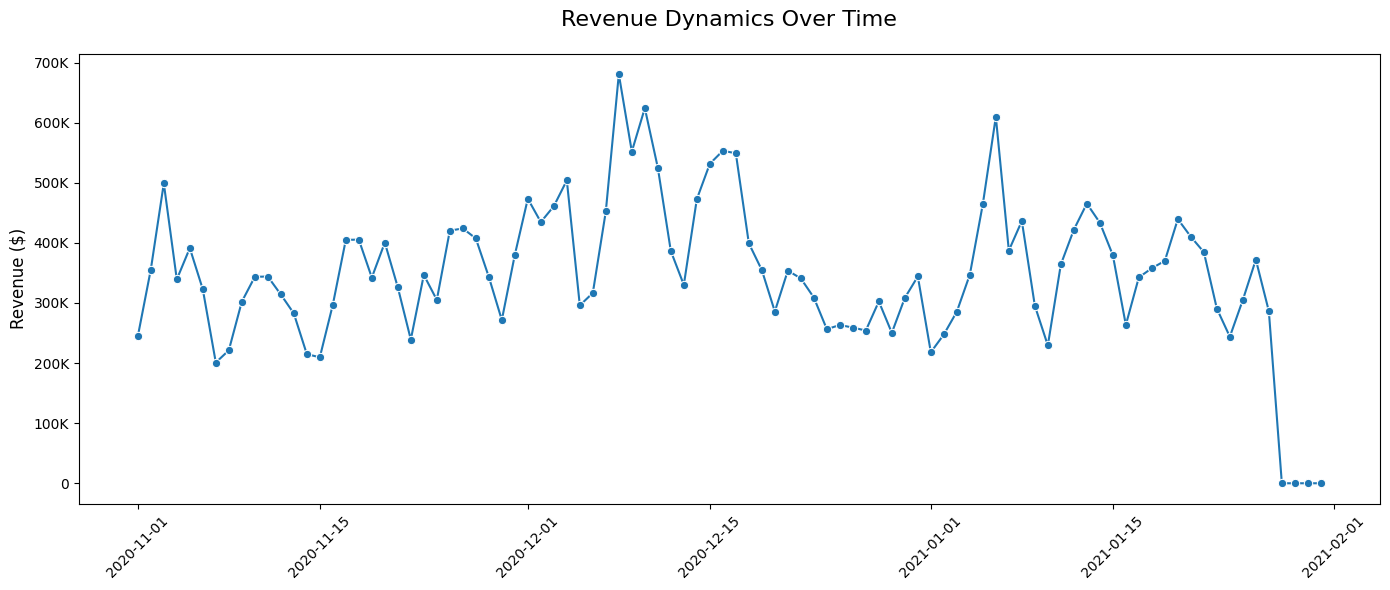

In [ ]:
sales_by_date = df.groupby("session_date")["price"].sum().reset_index(name="revenue")

plt.figure(figsize=(14, 6))

ax = sns.lineplot(
    data=sales_by_date,
    x="session_date",
    y="revenue",
    marker="o"
)

plt.title("Revenue Dynamics Over Time", fontsize=16, pad=20)
plt.xlabel("", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)

ax.yaxis.set_major_formatter(FuncFormatter(format_money))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df["session_date"] = pd.to_datetime(df["session_date"])

period_df = df[
    (df["session_date"] >= "2021-01-20") &
    (df["session_date"] <= "2021-02-01")
].copy()

period_df

sales_check_jan_feb = (
    period_df
    .groupby("session_date")
    .agg(
        rows_cnt=("session_date", "count"),
        sessions_cnt=("ga_session_id", "nunique"),
        orders_cnt=("price", lambda x: x.fillna(0).gt(0).sum()),
        revenue=("price", "sum"),
        missing_price_cnt=("price", lambda x: x.isna().sum()),
        zero_price_cnt=("price", lambda x: x.fillna(0).eq(0).sum())
    )
    .reset_index()
    .sort_values("session_date")
)

sales_check_jan_feb

sales_check_jan_feb[[
    "session_date",
    "rows_cnt",
    "sessions_cnt",
    "orders_cnt",
    "revenue"
]]

df["session_date"] = pd.to_datetime(df["session_date"])

last_sales_date = df[df["price"].fillna(0) > 0]["session_date"].max()
last_dataset_date = df["session_date"].max()

print("Last date with sales:", last_sales_date)
print("Last date in dataset:", last_dataset_date)

Last date with sales: 2021-01-27 00:00:00
Last date in dataset: 2021-01-31 00:00:00


The zero revenue at the end of January is most likely caused by a data quality issue rather than a real sales decline. Sessions are still present, but orders and revenue are completely missing from 2021-01-28 onward.

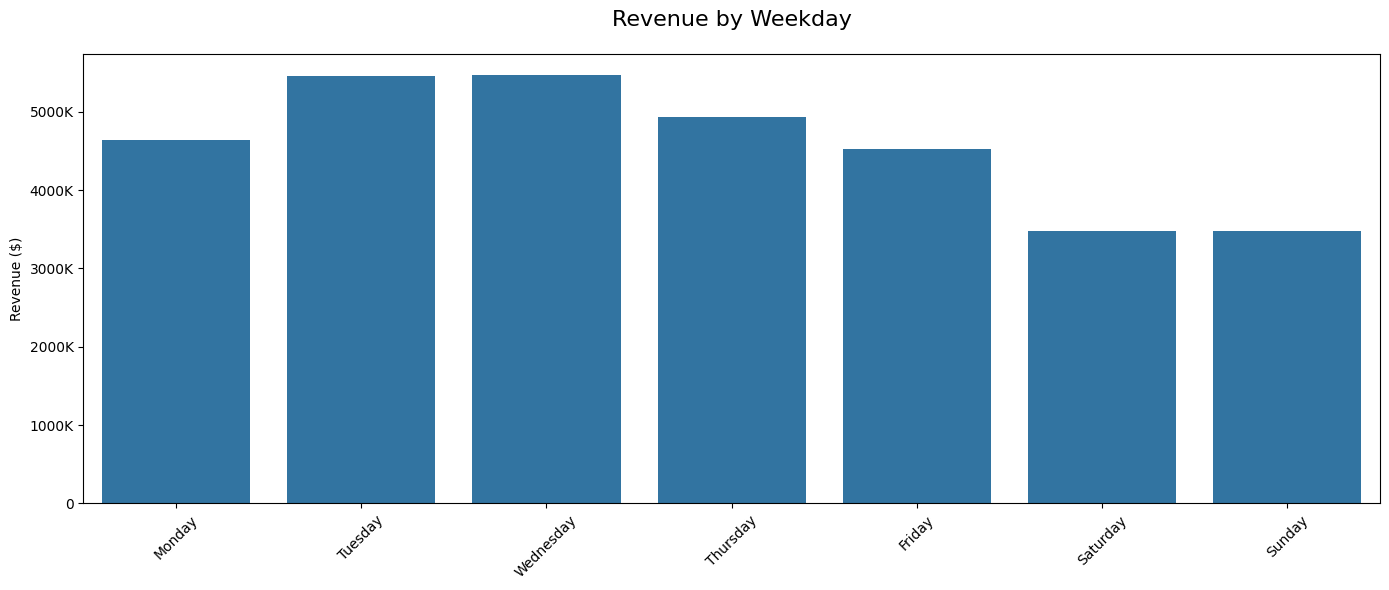

In [ ]:
sales_by_weekday = sales_by_date.copy()

sales_by_weekday["session_date"] = pd.to_datetime(
    sales_by_weekday["session_date"],
    errors="coerce"
)

sales_by_weekday = sales_by_weekday.dropna(subset=["session_date"])

sales_by_weekday["weekday"] = (
    sales_by_weekday["session_date"]
    .dt.day_name()
)

weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

sales_by_weekday = (
    sales_by_weekday
    .groupby("weekday", as_index=False)["revenue"]
    .sum()
    .set_index("weekday")
    .reindex(weekday_order)
    .reset_index()
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=sales_by_weekday,
    x="weekday",
    y="revenue"
)

plt.title("Revenue by Weekday", fontsize=16, pad=20)
plt.xlabel("")
plt.ylabel("Revenue ($)")

ax.yaxis.set_major_formatter(FuncFormatter(format_k))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

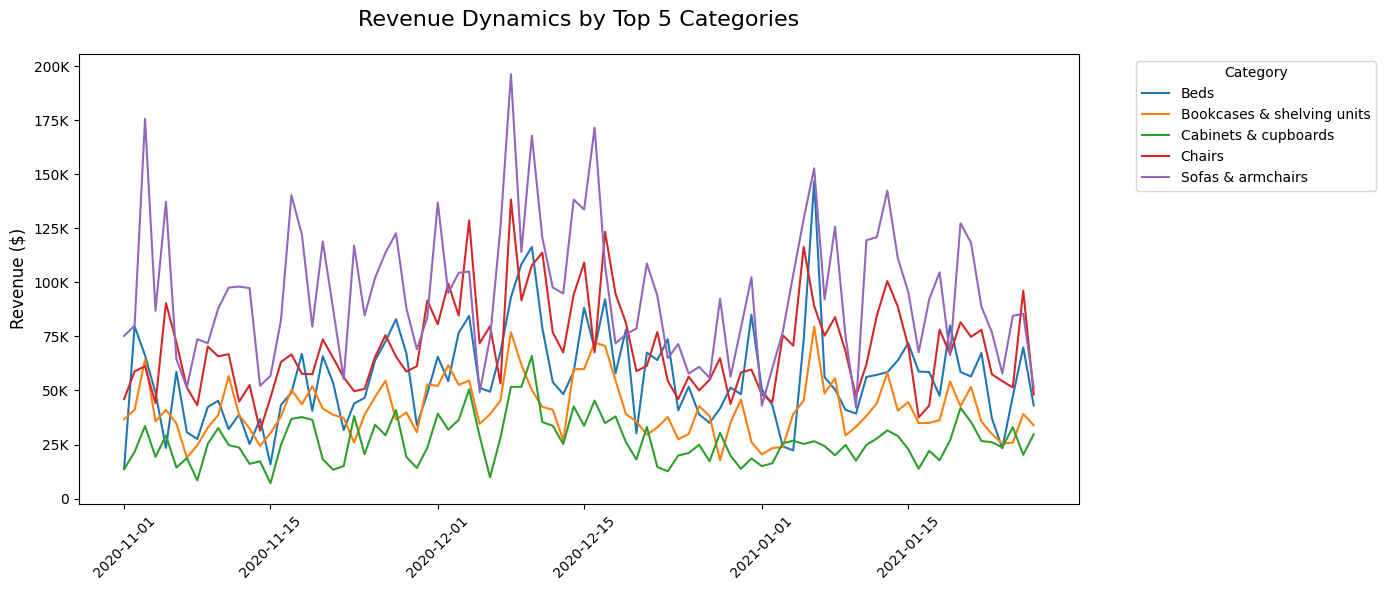

In [ ]:
top_5_categories = (
    df.groupby("category")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

top_5_categories_sales_by_datetime = (
    df[df["category"].isin(top_5_categories)]
    .groupby(["session_date", "category"])["price"]
    .sum()
    .reset_index(name="revenue")
)

top_5_categories_sales_by_datetime["session_date"] = pd.to_datetime(
    top_5_categories_sales_by_datetime["session_date"]
)

top_5_categories_sales_by_datetime = top_5_categories_sales_by_datetime.sort_values(
    "session_date"
)

plt.figure(figsize=(14, 6))

ax = sns.lineplot(
    data=top_5_categories_sales_by_datetime,
    x="session_date",
    y="revenue",
    hue="category",
)

plt.title("Revenue Dynamics by Top 5 Categories", fontsize=16, pad=20)
plt.xlabel("", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)

ax.yaxis.set_major_formatter(FuncFormatter(format_money))

plt.xticks(rotation=45)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

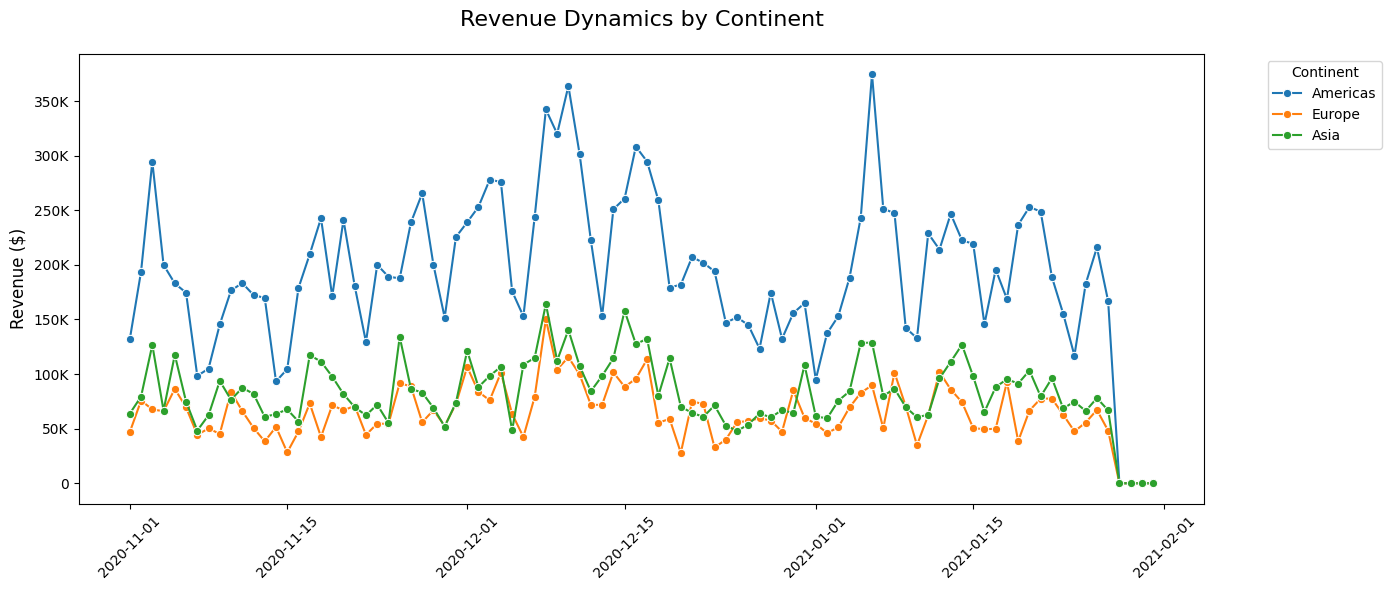

In [ ]:
continents = ["Americas", "Asia", "Europe"]

sales_by_date_continent = (
    df[df["continent"].isin(continents)]
    .groupby(["session_date", "continent"])["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(name="revenue")
)

plot_revenue_dynamics(
    data=sales_by_date_continent,
    hue_col="continent",
    title="Revenue Dynamics by Continent",
    legend_title="Continent"
)

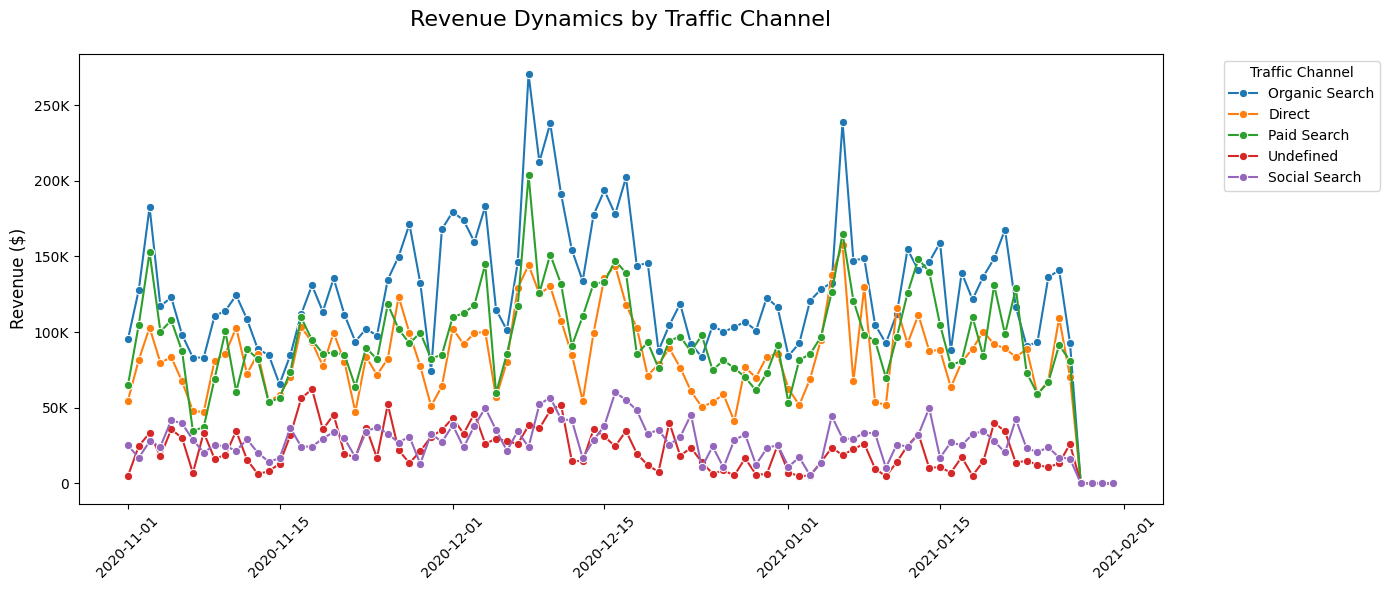

In [ ]:
sales_by_traffic_channel_date = df.groupby(["session_date", "traffic_channel"])["price"].sum().sort_values(ascending=False).reset_index(name = "revenue")

plot_revenue_dynamics(
    data=sales_by_traffic_channel_date,
    hue_col="traffic_channel",
    title="Revenue Dynamics by Traffic Channel",
    legend_title="Traffic Channel"
)

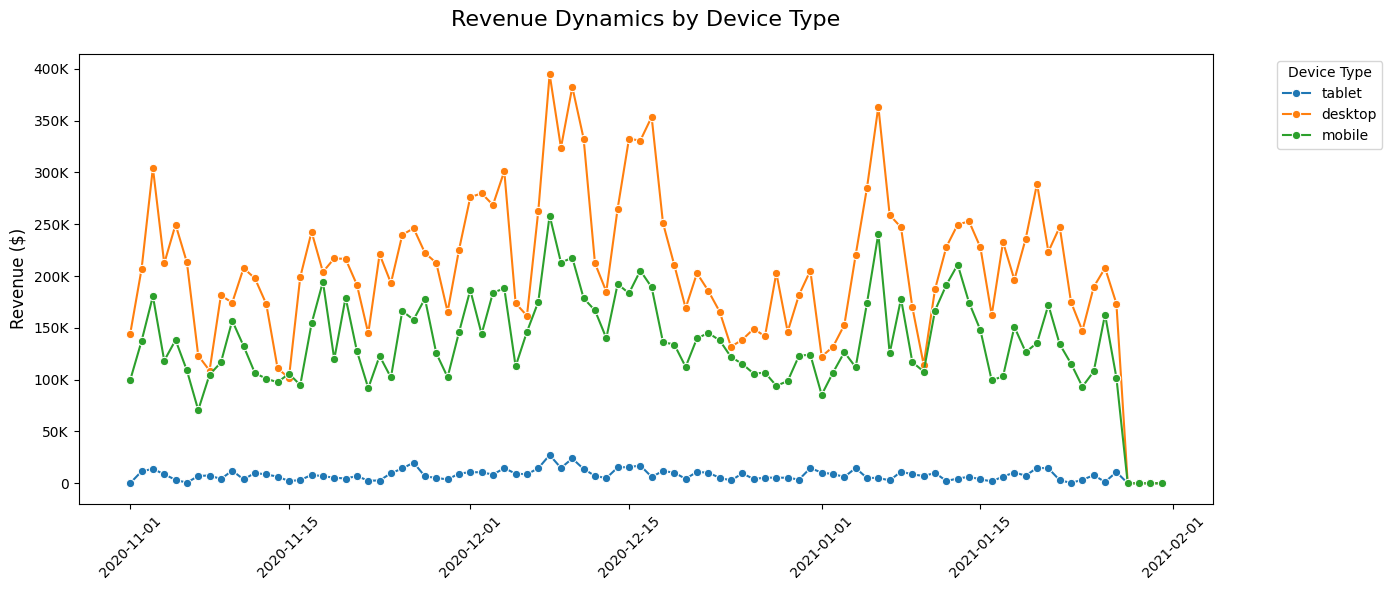

In [ ]:
sales_by_type_device_date = df.groupby(["session_date", "device"])["price"].sum().sort_values(ascending=False).reset_index(name = "revenue")

plot_revenue_dynamics(
    data=sales_by_type_device_date,
    hue_col="device",
    title="Revenue Dynamics by Device Type",
    legend_title="Device Type"
)

Overall, revenue shows strong daily fluctuations, with the highest peaks in the first half of December 2020 and at the beginning of January 2021. However, the analyzed period is too short to make a reliable conclusion about seasonality.

The drop to almost zero at the end of January should be checked separately, as it may indicate incomplete data or another data quality issue.

Sales are mainly driven by the Americas, desktop users, Organic Search traffic, and the top product categories, especially Sofas & armchairs, Chairs, and Beds. Across continents, traffic channels, device types, and product categories, revenue patterns generally move in a similar direction, suggesting that changes are mostly related to overall demand dynamics rather than isolated changes in one segment.

Weekday analysis shows higher total revenue on weekdays, especially Tuesday and Wednesday, and lower sales on weekends.

In [ ]:
session_cnt_by_traffic_channel_type_device = pd.pivot_table(
    df.dropna(subset=["traffic_channel", "device", "ga_session_id"]),
    index="traffic_channel",
    columns="device",
    values="ga_session_id",
    aggfunc="nunique",
    fill_value=0
)

display("Session count by traffic channel and device type", session_cnt_by_traffic_channel_type_device)


'Session count by traffic channel and device type'

device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


In [ ]:
top_10_categories = (
    df.groupby("category")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
    .tolist()
)

top_5_countries = (
    df.groupby("country")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

sales_by_category_country = pd.pivot_table(
    df[
        df["category"].isin(top_10_categories) &
        df["country"].isin(top_5_countries)
    ],
    index="category",
    columns="country",
    values="price",
    aggfunc="sum",
    fill_value=0
)

sales_by_category_country = sales_by_category_country.reindex(
    index=top_10_categories,
    columns=top_5_countries
)

display("Total sales by top 10 categories and top 5 countries", sales_by_category_country)

'Total sales by top 10 categories and top 5 countries'

country,United States,India,Canada,United Kingdom,France
category,,,,,
Sofas & armchairs,3707144.5,788430.0,692427.5,234812.0,187735.0
Chairs,2619773.8,544309.2,417740.8,188519.4,134029.4
Beds,2213058.0,358319.5,354772.0,133816.0,116414.0
Bookcases & shelving units,1567606.9,364507.4,278981.9,113987.6,73830.0
Cabinets & cupboards,994545.5,191888.0,181802.0,71684.5,59101.5
Outdoor furniture,929245.2,162289.4,185322.8,57002.4,40486.4
Tables & desks,777865.0,186157.5,132678.0,49374.0,42299.0
Chests of drawers & drawer units,382388.0,73111.0,71952.0,36784.0,21544.5
Bar furniture,330805.0,57657.0,51724.0,22103.0,11199.0


In [ ]:
df["session_date"] = pd.to_datetime(df["session_date"])

orders_by_month = (
    df[df["price"].notna()]
    .assign(month=df["session_date"].dt.to_period("M"))
    .groupby("month")["ga_session_id"]
    .nunique()
    .reset_index(name="orders_cnt")
)

orders_by_month


,month,orders_cnt
0,2020-11,10540
1,2020-12,12903
2,2021-01,10095


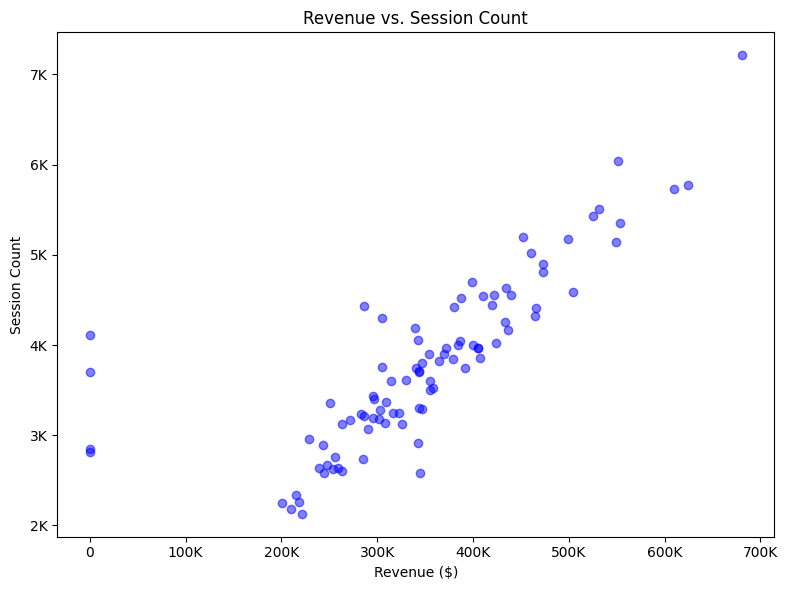

Correlation without zero revenue: 0.9313146607045042
p-value: 1.7394621412995947e-39
Number of observations: 88


In [ ]:
session_count_by_sales_datetime = df.groupby("session_date").agg(
    session_cnt = ("ga_session_id", "nunique"),
    revenue = ("price", "sum")
).sort_values("revenue", ascending = False).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    session_count_by_sales_datetime["revenue"],
    session_count_by_sales_datetime["session_cnt"],
    color="blue",
    alpha=0.5
)

ax.set_title("Revenue vs. Session Count")
ax.set_xlabel("Revenue ($)")
ax.set_ylabel("Session Count")

ax.xaxis.set_major_formatter(FuncFormatter(format_money))
ax.yaxis.set_major_formatter(FuncFormatter(format_k))

plt.tight_layout()
plt.show()

data_without_zero_revenue = session_count_by_sales_datetime[session_count_by_sales_datetime["revenue"] > 0]

r, p_value = pearsonr(
    data_without_zero_revenue["revenue"],
    data_without_zero_revenue["session_cnt"]
)

print("Correlation without zero revenue:", r)
print("p-value:", p_value)
print("Number of observations:", len(data_without_zero_revenue))

The chart shows a positive relationship between the number of sessions and revenue: in general, the more sessions there are, the higher the revenue.

In [ ]:
sales_by_continent_datetime, continent_corr, continent_stat = statistic_analysis(
    data=df,
    param1="continent",
    param2="price",
    aggfunc="sum",
    top_numeric=3
)
sales_by_traffic_channel_datetime, traffic_corr, traffic_stat = statistic_analysis(
    data=df,
    param1="traffic_channel",
    param2="price",
    aggfunc="sum"
)
sales_by_category_datetime, category_corr, category_stat = statistic_analysis(
    data=df,
    param1="category",
    param2="price",
    aggfunc="sum",
    top_numeric=5
)
display("Statistical analysis by continent", continent_stat)
display("Statistical analysis by traffic channel", traffic_stat)
display("Statistical analysis by categories", category_stat)


'Statistical analysis by continent'

,group_1,group_2,correlation,p_value,is_significant
0,Americas,Asia,0.792025,5.409189e-21,True
1,Americas,Europe,0.770586,2.671449e-19,True
2,Asia,Europe,0.768427,3.864946e-19,True


'Statistical analysis by traffic channel'

,group_1,group_2,correlation,p_value,is_significant
0,Direct,Organic Search,0.837833,2.190420e-25,True
1,Direct,Paid Search,0.814072,5.896435e-23,True
2,Direct,Social Search,0.604060,1.831889e-10,True
3,Direct,Undefined,0.517505,1.275436e-07,True
4,Organic Search,Paid Search,0.870086,2.142003e-29,True
5,Organic Search,Social Search,0.583117,1.066192e-09,True
6,Organic Search,Undefined,0.526068,7.228214e-08,True
7,Paid Search,Social Search,0.596428,3.532284e-10,True
8,Paid Search,Undefined,0.521961,9.509609e-08,True
9,Social Search,Undefined,0.455126,5.161928e-06,True


'Statistical analysis by categories'

,group_1,group_2,correlation,p_value,is_significant
0,Beds,Bookcases & shelving units,0.592913,1.154998e-09,True
1,Beds,Cabinets & cupboards,0.514609,2.910930e-07,True
2,Beds,Chairs,0.554500,2.079183e-08,True
3,Beds,Sofas & armchairs,0.535378,7.687333e-08,True
4,Bookcases & shelving units,Cabinets & cupboards,0.539428,5.867225e-08,True
5,Bookcases & shelving units,Chairs,0.637090,2.504550e-11,True
6,Bookcases & shelving units,Sofas & armchairs,0.666194,1.406972e-12,True
7,Cabinets & cupboards,Chairs,0.572870,5.465903e-09,True
8,Cabinets & cupboards,Sofas & armchairs,0.657563,3.415056e-12,True
9,Chairs,Sofas & armchairs,0.578248,3.638833e-09,True


Sales correlations were analyzed for the top 3 continents, traffic channels, and top 5 product categories.

For continents, all pairs show strong positive correlations. The correlation coefficients are around 0.77–0.79, and all p-values are below 0.05. This means that sales in the Americas, Asia, and Europe tend to move in the same direction over time, and these relationships are statistically significant.

For traffic channels, all relationships are also statistically significant. The strongest correlations are observed between Organic Search and Paid Search, Direct and Organic Search, and Direct and Paid Search. This suggests that sales from the main traffic channels tend to grow or decrease together.

For product categories, all correlations are statistically significant as well. The relationships are mostly moderate positive correlations, with coefficients around 0.51–0.67. This means that sales of the top product categories generally move in the same direction over time.

Overall, the analysis shows that sales dynamics are positively correlated across continents, traffic channels, and top product categories. However, correlation does not prove causation. These relationships may be influenced by general demand trends, seasonality, marketing activity, or overall traffic growth.

## **Statistical Analysis of Relationships and Group Differences**

In [ ]:
df["is_registered"] = (df["account_id"].notna())

sales_by_registration_status_datetime = pd.pivot_table(
    df,
    index="session_date",
        columns="is_registered",
        values="price",
        aggfunc="sum",
        fill_value=0
)
sales_by_registration_status_datetime
sales_by_registration_status_datetime = sales_by_registration_status_datetime.rename(
    columns={
        False: "not_registered_sales",
        True: "registered_sales"
    }
)
registered_sales = sales_by_registration_status_datetime["registered_sales"]
not_registered_sales = sales_by_registration_status_datetime["not_registered_sales"]
registered_sales.describe()
not_registered_sales.describe()

sales_difference = registered_sales - not_registered_sales

shapiro_result = shapiro(sales_difference)

if shapiro_result.pvalue >= 0.05:
    test_name = "Paired t-test"
    stat, p_value = ttest_rel(registered_sales, not_registered_sales)
else:
    test_name = "Wilcoxon signed-rank test"
    stat, p_value = wilcoxon(registered_sales, not_registered_sales)

print("Test:", test_name)
print("p-value:", p_value)
print("Is significant:", p_value < 0.05)


Test: Wilcoxon signed-rank test
p-value: 3.732014234846569e-16
Is significant: True


The difference between sales of registered and not registered users is statistically significant. Daily sales totals of registered and not registered users differ significantly.

In [ ]:
session_cnt_by_traffic_channel = df.groupby("traffic_channel")["ga_session_id"].nunique().sort_values(ascending=False).reset_index()

session_cnt_by_traffic_channel.columns = ["traffic_channel", "session_cnt"]

display("Session count by traffic channel", session_cnt_by_traffic_channel)

chi_stat, p_value = chisquare(
    session_cnt_by_traffic_channel["session_cnt"]
)

print("Chi-square statistic:", chi_stat)
print("p-value:", p_value)
print("Is significant:", p_value < 0.05)

'Session count by traffic channel'

,traffic_channel,session_cnt
0,Organic Search,124425
1,Paid Search,94341
2,Direct,81382
3,Social Search,27914
4,Undefined,21483


Chi-square statistic: 111705.27557253001
p-value: 0.0
Is significant: True


Session distribution differs significantly across traffic channels. Organic Search, Paid Search, and Direct are the main sources of sessions.

In [ ]:
sessions_eu_americas = df[df["continent"].isin(["Europe", "Americas"])] .drop_duplicates(subset=["ga_session_id"]).copy()

sessions_eu_americas["is_organic"] = (
    sessions_eu_americas["traffic_channel"]
    .str.contains("organic", case=False, na=False)
)
organic_contingency_table = pd.crosstab(
    sessions_eu_americas["continent"],
    sessions_eu_americas["is_organic"]
)

organic_contingency_table = organic_contingency_table.reindex(
    columns=[False, True],
    fill_value=0
)

display("Organic vs non-organic sessions by continent Europe and Americas", organic_contingency_table)

organic_share_result = pd.DataFrame({
    "organic_sessions": organic_contingency_table[True],
    "total_sessions": organic_contingency_table.sum(axis=1),
    "organic_share": organic_contingency_table[True] / organic_contingency_table.sum(axis=1)
})

display("Organic session share by continent", organic_share_result)

chi2_stat, p_value, dof, expected = chi2_contingency(organic_contingency_table)

print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)
print("Degrees of freedom:", dof)
print("Is significant:", p_value < 0.05)

if p_value < 0.05:
    print("Conclusion: The share of organic sessions differs significantly between Europe and Americas.")
else:
    print("Conclusion: There is no statistically significant difference in the share of organic sessions between Europe and Americas.")


'Organic vs non-organic sessions by continent Europe and Americas'

is_organic,False,True
continent,,
Americas,124508,68671
Europe,41940,23195


'Organic session share by continent'

,organic_sessions,total_sessions,organic_share
continent,,,
Americas,68671,193179,0.355479
Europe,23195,65135,0.356107


Chi-square statistic: 0.08110059225974814
p-value: 0.7758114260479175
Degrees of freedom: 1
Is significant: False
Conclusion: There is no statistically significant difference in the share of organic sessions between Europe and Americas.


The share of organic traffic is almost identical in Europe and the Americas, and the difference is not statistically significant.

In [ ]:
## Tableau Dashboard Dataset Preparation

df_tableau = df.copy()

df_tableau["is_registered"] = df_tableau["account_id"].notna()

df_tableau["registration_status"] = df_tableau["is_registered"].map({
    True: "Registered",
    False: "Not registered"
})

df_tableau["is_organic"] = (
    df_tableau["traffic_channel"]
    .str.contains("organic", case=False, na=False)
)


df_tableau["revenue"] = df_tableau["price"].fillna(0)
df_tableau["order_cnt"] = df_tableau["price"].notna().astype(int)

df_tableau
df_tableau.to_csv("tableau_ecommerce_dashboard_data.csv", index=False)

files.download("tableau_ecommerce_dashboard_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Final Business Conclusions**

The analysis shows that revenue is mainly driven by the Americas, especially the United States, as well as desktop users, Organic Search traffic, and the top product categories such as Sofas & armchairs, Chairs, and Beds.

Revenue shows strong daily fluctuations, with visible peaks in December 2020 and early January 2021. However, the analyzed period is too short to confirm a reliable seasonal pattern.

The sharp revenue drop at the end of January should be treated as a potential data quality issue rather than a real business decline. From 2021-01-28 onward, the dataset still contains a significant number of sessions, but orders and revenue drop to zero. This suggests that session data continues to be available, while sales/order data may be missing or not properly tracked for this period.

The statistical analysis confirms that revenue dynamics are positively correlated across major continents, traffic channels, and product categories. Session count also has a strong positive relationship with revenue, which means that days with more sessions generally tend to generate higher sales.

Overall, the company’s performance is strongly concentrated in several key segments: the Americas, desktop users, Organic Search traffic, and leading product categories. At the same time, areas such as Undefined traffic, tablet users, and the missing sales data at the end of January should be investigated further.

https://public.tableau.com/views/Book134444/Dashboard1?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link
